In [1]:
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta

In [2]:
df = pd.read_csv('Cleaned Malaria Data.csv').drop(columns=['rainfall', 'prev_month_rainfall'])
df['visit_month'] = pd.to_datetime(df['visit_month'])
nasa_raw = pd.read_csv('Master Data.csv')

In [3]:
num = []
for x in df['village_code'].unique():
    num.append(len(df[df['village_code'] == x]))
np.mean(num)

np.float64(20.819148936170212)

In [4]:
# Define month names (12 months + annual summary column)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Annual']

# Load your data and assign column names
nasa_raw.columns = ['param', 'year'] + months

# Reshape to long format
nasa_long = nasa_raw.melt(
    id_vars=['param', 'year'],
    value_vars=months,
    var_name='month',
    value_name='value'
)

# Drop rows for 'Annual' (if you don't want them in the final table)
nasa_long = nasa_long[nasa_long['month'] != 'Annual']

# Convert month names to numbers (Jan → 1, etc.)
nasa_long['month_num'] = pd.to_datetime(nasa_long['month'], format='%b').dt.month

# Create a datetime column (e.g. 2016-12-01)
nasa_long['visit_month'] = pd.to_datetime(dict(year=nasa_long['year'], month=nasa_long['month_num'], day=1))

# Pivot so each param becomes a column
nasa_wide = nasa_long.pivot_table(
    index='visit_month',
    columns='param',
    values='value',
    aggfunc='first'
).reset_index()

# Optional: remove columns name
nasa_wide.columns.name = None

In [5]:
# Merge climate data into your main malaria dataframe based on 'visit_month'
df = df.merge(
    nasa_wide,
    on='visit_month',
    how='left'  # Ensures all rows in df are preserved, even if some dates are missing in nasa_wide
)

In [6]:
nasa_wide

,visit_month,PRECTOTCORR,PRECTOTCORR_SUM,RH2M,T2M,T2M_MAX,T2M_MIN,T2M_RANGE
0,2014-01-01,8.48,263.01,86.60,26.61,32.48,19.32,6.87
1,2014-02-01,13.57,380.07,86.92,26.42,32.82,21.63,6.97
2,2014-03-01,1.48,46.00,83.52,26.54,33.05,21.02,8.56
3,2014-04-01,2.53,75.99,77.19,25.48,34.13,18.67,10.16
4,2014-05-01,1.26,38.95,73.50,24.53,34.99,17.17,11.81
...,...,...,...,...,...,...,...,...
91,2021-08-01,0.25,7.62,67.24,23.74,37.28,14.06,14.17
92,2021-09-01,0.56,16.78,63.17,25.92,40.21,15.96,14.39
93,2021-10-01,0.36,11.07,57.43,28.04,44.57,17.08,15.25
94,2021-11-01,0.96,28.93,59.88,30.14,45.87,19.18,15.47


In [7]:
# List of climate parameters to lag
climate_params = ['PRECTOTCORR', 'PRECTOTCORR_SUM', 'RH2M', 'T2M',
                  'T2M_MAX', 'T2M_MIN', 'T2M_RANGE']

# Respective month lags
for param in climate_params:
    df[f'prev_{param}'] = df.groupby('village_code')[param].shift(1)
    df[f'prev2_{param}'] = df.groupby('village_code')[param].shift(2)
    df[f'prev3_{param}'] = df.groupby('village_code')[param].shift(3)
    df[f'prev4_{param}'] = df.groupby('village_code')[param].shift(4)


In [8]:
df.columns

Index(['village_code', 'visit_month', 'spray_status', 'total_residents',
       'clinic_tests', 'total_rdts', 'avg_distance_to_health_facility_km',
       'incidence_per_1000', 'positivity_rate', 'dist_missing', 'PRECTOTCORR',
       'PRECTOTCORR_SUM', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE',
       'prev_PRECTOTCORR', 'prev2_PRECTOTCORR', 'prev3_PRECTOTCORR',
       'prev4_PRECTOTCORR', 'prev_PRECTOTCORR_SUM', 'prev2_PRECTOTCORR_SUM',
       'prev3_PRECTOTCORR_SUM', 'prev4_PRECTOTCORR_SUM', 'prev_RH2M',
       'prev2_RH2M', 'prev3_RH2M', 'prev4_RH2M', 'prev_T2M', 'prev2_T2M',
       'prev3_T2M', 'prev4_T2M', 'prev_T2M_MAX', 'prev2_T2M_MAX',
       'prev3_T2M_MAX', 'prev4_T2M_MAX', 'prev_T2M_MIN', 'prev2_T2M_MIN',
       'prev3_T2M_MIN', 'prev4_T2M_MIN', 'prev_T2M_RANGE', 'prev2_T2M_RANGE',
       'prev3_T2M_RANGE', 'prev4_T2M_RANGE'],
      dtype='object')

In [9]:
# <b><center>Now let's do what my past self couldn't!</center></b>

In [10]:
## Part I. Filling NaNs

In [11]:
# This is the df that contains all the nans that we want to deal with
nan_df = df[df.isna().any(axis=1)].copy()

In [12]:
# This is a very inefficient way to do this but I couldn't find a way to solve this problem with vectorized operations
for index, row in nan_df.iterrows():
    for param in climate_params:
        nan_df.loc[index, f'prev_{param}'] = \
        nasa_wide.loc[nasa_wide['visit_month'] == row['visit_month'] - relativedelta(months=1), param].iloc[0]
# I didn't fill it with the rest of the lag features. Can you see why?

In [13]:
nan_df[[f'prev_{param}' for param in climate_params] + ['visit_month']].isna().any()
# It's working!

prev_PRECTOTCORR        False
prev_PRECTOTCORR_SUM    False
prev_RH2M               False
prev_T2M                False
prev_T2M_MAX            False
prev_T2M_MIN            False
prev_T2M_RANGE          False
visit_month             False
dtype: bool

In [14]:
lags = [2, 3, 4]

In [15]:
# This fills 2-, 3-, and 4-month lag features automatically
for index, row in nan_df.iterrows():
    for param in climate_params:
        for lag in lags:
            nan_df.loc[index, f'prev{lag}_{param}'] = \
            nasa_wide.loc[nasa_wide['visit_month'] == row['visit_month'] - relativedelta(months=lag), param].iloc[0]

In [16]:
np.sum(nan_df.isna().any()) == 0
# YES!!

np.True_

In [17]:
df.update(nan_df)

np.sum(df.isna().any()) == 0
# DONE!

np.True_

In [18]:
## Part II. Adding prev_incidence_per_1000

In [19]:
df[f'prev_incidence_per_1000'] = df.groupby('village_code')['incidence_per_1000'].shift(1)

In [20]:
df.to_csv('Full dataset.csv')

In [21]:
df = df[df['prev_incidence_per_1000'].notna()]
# I really don't have a way of filling this like I did with the climate data. Plus it's just 4% of the data so it's fine

In [22]:
df.isna().any().sum()
# DONE!!

np.int64(0)

### I wanted to create a malaria proneness index because incidences vary per village and none of the parameters in the dataframe are good ones to give info about the village (they cause overfitting)
### See in Model Training 2.ipynb (Brainspace) for more info

$
\text{MPI}_v = w_1 \cdot \text{IncidenceAvg}_v 
+ w_2 \cdot \text{DistToClinic}_v 
+ w_3 \cdot \text{PositivityRate}_v 
- w_4 \cdot \text{SprayCoverage}_v
$

In [23]:
# I just remembered that I imputed nans in the original data with the median and flagged them as True (1) in dist_missing
# We can't really do that here. MPI needs to use avg_distance_to_health_facility_km directly
# So I created a new temporary column named 'avg_edited' (I know it's not a good name) to fill the missing ones with arbitrarily large values.
# I had evidence that samples with NaNs for distance from health facilities consitently had higher malaria incidences
# Meaning the recoreders were just too lazy to measure it because it was too far?
# Seems like a good generalization
df['avg_edited'] = df['avg_distance_to_health_facility_km']

array([[<Axes: title={'center': '0'}>]], dtype=object)

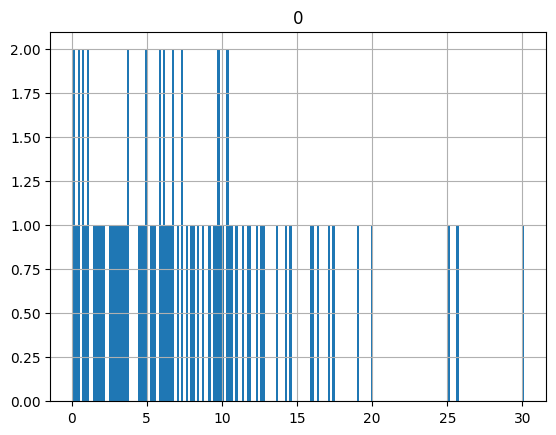

In [24]:
pd.DataFrame(df['avg_distance_to_health_facility_km'].unique()).hist(bins=200)

In [25]:
df.loc[df['dist_missing'] == 1, 'avg_edited'] = df['avg_distance_to_health_facility_km'].max() * 1.45
# I found that +45% increase from the non-NaN maximum for the missing ones should be a good representative of "too far"

In [26]:
mpi_df = pd.DataFrame({'village_code': [],'incidence_per_1000': [], 'avg_edited': [], 
                       'positivity_rate': [], 'spray_status': []})
mpi_df['village_code'] = df['village_code'].unique()

In [27]:
# I wasn't sure how to calculate the mean and create a new column at once so I created a (4, -1) array to contain the values
values = [[], [], [], []]
parameters = ['incidence_per_1000', 'avg_edited', 'positivity_rate', 'spray_status']
for index, parameter in enumerate(parameters):
    for village in df['village_code'].unique():
        values[index].append(df.loc[df['village_code'] == village, parameter].describe()['mean'])
# Now we finally create the column and fill them with the average values
for index, parameter in enumerate(parameters):
    mpi_df[parameter] = values[index]

In [28]:
mpi_df.describe() # It works
# But we still need normalization to fit it into a meaningful index

,village_code,incidence_per_1000,avg_edited,positivity_rate,spray_status
count,187.000000,187.000000,187.000000,187.000000,187.000000
mean,7114.272727,92.630829,22.480802,0.607505,0.433155
std,71.682285,119.875279,18.503016,0.106022,0.496842
min,7001.000000,0.000000,0.100000,0.000000,0.000000
25%,7049.500000,21.098409,5.300000,0.539091,0.000000
50%,7114.000000,50.105000,12.600000,0.594000,0.000000
75%,7177.500000,119.151591,43.645000,0.687727,1.000000
max,7240.000000,891.630000,43.645000,1.000000,1.000000


In [29]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [30]:
scaler = MinMaxScaler()
for x in parameters:
    mpi_df[x] = scaler.fit_transform(np.array(mpi_df[x]).reshape(-1, 1))
# We just scaled everything with min-max to keep it simple

<Axes: >

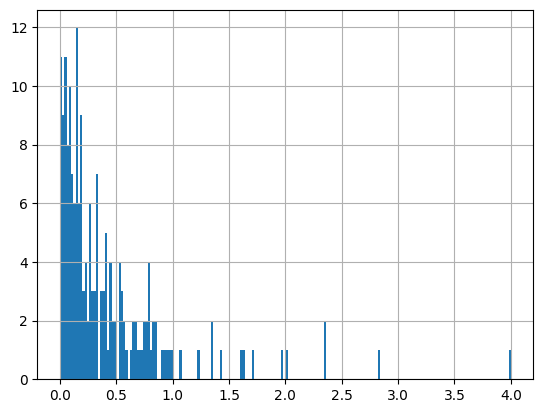

In [31]:
(mpi_df['incidence_per_1000'] * 4).hist(bins=200)

In [32]:
W = [4, .8, 1, -.5]
mpi_df['mpi'] = W[0] * mpi_df['incidence_per_1000'] + W[1] * mpi_df['avg_edited'] + \
                W[2] * mpi_df['positivity_rate'] + W[3] * mpi_df['spray_status']
# This is the recipe for a great MPI. (Don't forget to make the weight for spray_status negative)

In [33]:
mpi_df.sort_values('mpi', ascending=0)['village_code']
# I compared this with df.sort_values('incidence_per_1000', ascending=0)['village_code'] and it's very similar! 🥳

42     7045
145    7184
173    7223
99     7122
120    7149
       ... 
107    7130
151    7191
7      7008
3      7004
4      7005
Name: village_code, Length: 187, dtype: int64

In [34]:
# We do not need this column any more
df.drop(columns=['avg_edited'], inplace=True)

In [35]:
# Can you see why I didn't just say df['mpi'] = mpi_df['mpi']?
df['mpi'] = 0

In [36]:
for x in mpi_df['village_code']:
    df.loc[df['village_code'] == x, 'mpi'] = round(mpi_df.loc[mpi_df['village_code'] == x, 'mpi'].iloc[0], 3) # Let's round it to go easy on my PC

C:\Users\User\AppData\Local\Temp\ipykernel_2856\2644481050.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.183' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['village_code'] == x, 'mpi'] = round(mpi_df.loc[mpi_df['village_code'] == x, 'mpi'].iloc[0], 3) # Let's round it to go easy on my PC


In [37]:
df['mpi']
# It's filled!

1       1.183
2       1.183
3       1.183
4       1.183
5       1.183
        ...  
3908    1.575
3910    1.734
3911    1.734
3912    1.734
3913    1.734
Name: mpi, Length: 3726, dtype: float64

In [38]:
df.isna().any().sum()
# DONE!

np.int64(0)

In [39]:
# Finally
df.to_csv('Final Dataset.csv', index_label=False)

# <center>We have successfully cleaned 100% of the data. And added richer features!<br/>YES!!</center>

In [40]:
df['mpi'].describe()

count    3726.000000
mean        1.192052
std         0.708328
min         0.059000
25%         0.630000
50%         1.086000
75%         1.678000
max         5.288000
Name: mpi, dtype: float64